In [15]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import os
from PIL import Image

# 1. Define the Custom RGB Converter as specified in the paper
class ConvertToRGB(object):
    """Converts images to RGB format to ensure compatibility with ImageNet pretrained models."""
    def __call__(self, img):
        if img.mode != 'RGB':
            return img.convert('RGB')
        return img

In [16]:
# Standard ImageNet normalization values
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training Transformations
train_transforms = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Validation/Test Transformations
test_transforms = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Preprocessing pipelines successfully constructed.")

Preprocessing pipelines successfully constructed.


In [ ]:



import os
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Point directly to the root of the split folders
base_dir = os.path.join(dataset_path, 'Combined_Dataset_12856', 'Combined_Dataset_12856')

# Map to the specific split directories based on your output
train_dir = os.path.join(base_dir, 'Train')
val_dir = os.path.join(base_dir, 'Validate')
test_dir = os.path.join(base_dir, 'Test')

print("Re-mapping DataLoaders to the correct subdirectories...")

try:
    # Initialize datasets using the correct paths
    train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
    val_dataset = ImageFolder(root=val_dir, transform=test_transforms)
    test_dataset = ImageFolder(root=test_dir, transform=test_transforms)

    # Initialize DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

    print("\n--- Corrected Dataset Loading ---")
    print(f"Detected Classes: {train_dataset.classes}") # Verify this says Normal, Pneumonia, Tuberculosis
    print(f"Training images: {len(train_dataset)}")
    print(f"Validation images: {len(val_dataset)}")
    print(f"Test images: {len(test_dataset)}")

except FileNotFoundError as e:
    print(f"Directory Error: {e}")

Re-mapping DataLoaders to the correct subdirectories...

--- Corrected Dataset Loading ---
Detected Classes: ['Normal', 'Pneumonia', 'TB']
Training images: 11557
Validation images: 15
Test images: 1284


In [18]:
import torch.nn as nn

def build_custom_classifier(in_features):
    """
    Constructs the custom MLP head specified in the methodology.
    Architecture: Linear(in, 512) -> Dropout(0.2) -> ReLU -> Linear(512, 128) ->
                  Dropout(0.2) -> ReLU -> Linear(128, 32) -> Dropout(0.2) ->
                  ReLU -> Linear(32, 3)
    """
    return nn.Sequential(
        nn.Linear(in_features, 512),
        nn.Dropout(p=0.2),
        nn.ReLU(),

        nn.Linear(512, 128),
        nn.Dropout(p=0.2),
        nn.ReLU(),

        nn.Linear(128, 32),
        nn.Dropout(p=0.2),
        nn.ReLU(),

        nn.Linear(32, 3) # 3 output classes: Normal, Pneumonia, TB
    )

print("Custom Multi-Layer Perceptron head ready.")

Custom Multi-Layer Perceptron head ready.


In [19]:
import torchvision.models as models
import torch.nn as nn

def initialize_model(model_name, num_classes=3):
    """
    Instantiates a pretrained ImageNet backbone and attaches the custom MLP head.
    """
    model = None

    if model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        # Freeze backbone
        for param in model.parameters():
            param.requires_grad = False
        # Attach custom head
        in_features = model.classifier.in_features
        model.classifier = build_custom_classifier(in_features)

    elif model_name in ["resnet50", "resnet101"]:
        if model_name == "resnet50":
            model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        else:
            model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
        # Freeze backbone
        for param in model.parameters():
            param.requires_grad = False
        # Attach custom head
        in_features = model.fc.in_features
        model.fc = build_custom_classifier(in_features)

    elif model_name in ["efficientnet_b0", "efficientnet_b4"]:
        if model_name == "efficientnet_b0":
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        else:
            model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        # The paper notes the entire classifier block was retrained for EfficientNets
        in_features = model.classifier[1].in_features
        model.classifier = build_custom_classifier(in_features)

    else:
        raise ValueError("Invalid model name specified.")

    return model

# Let's test the instantiation of a single model to verify the architecture
test_model = initialize_model("resnet50")
print("ResNet50 successfully initialized with Custom MLP Head.")

ResNet50 successfully initialized with Custom MLP Head.


In [20]:
import torch.optim as optim
import time
import copy

# Detect hardware
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Compute Device: {device}")

def train_model(model, model_name, train_loader, val_loader, num_epochs=25, patience=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Optimizer and Scheduler as defined in the paper
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass and optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model and handle Early Stopping
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    # Save the physical weights file
                    torch.save(model.state_dict(), f'{model_name}_best_weights.pth')
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

        print()

    time_elapsed = time.time() - start_time
    print(f'Training complete for {model_name} in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

print("Training engine compiled and ready.")

Compute Device: cuda:0
Training engine compiled and ready.


In [21]:
# Initialize a fresh ResNet50 with our custom MLP head
sanity_model = initialize_model("resnet50")

print("Initiating 1-Epoch Sanity Check...")

# Run the training engine for exactly 1 epoch
sanity_model = train_model(
    model=sanity_model,
    model_name="resnet50_sanity",
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=1,
    patience=3
)

print("\nSanity Check Complete! If you see 'Training complete' above with no tracebacks, your tensors are aligned perfectly.")

Initiating 1-Epoch Sanity Check...
Epoch 1/1
----------
Train Loss: 0.3824 Acc: 0.8967
Val Loss: 0.2872 Acc: 0.9083

Training complete for resnet50_sanity in 1m 10s
Best val Acc: 0.908304

Sanity Check Complete! If you see 'Training complete' above with no tracebacks, your tensors are aligned perfectly.


In [25]:
from google.colab import drive
import os

# Mount Drive to safely store weights
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/Ensemble_Weights/'
os.makedirs(save_dir, exist_ok=True)

# The 5 architectures required by the paper
models_to_train = [
    "densenet121",
    "resnet50",
    "resnet101",
    "efficientnet_b0",
    "efficientnet_b4"
]

trained_models = {}

print("Commencing Full Ensemble Training Suite...")

for model_name in models_to_train:
    print(f"\n{'='*40}")
    print(f" INITIALIZING {model_name.upper()}")
    print(f"{'='*40}")

    # Initialize fresh model and attach custom MLP
    current_model = initialize_model(model_name)

    # Train the model (Using 25 epochs as a standard ceiling, early stopping will likely halt it sooner)
    trained_model = train_model(
        model=current_model,
        model_name=os.path.join(save_dir, model_name), # Saves directly to your Drive
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=25,
        patience=3
    )

    # Store in memory for immediate evaluation if needed
    trained_models[model_name] = trained_model

print("\nAll models have been successfully trained and weights are secured in Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Commencing Full Ensemble Training Suite...

 INITIALIZING DENSENET121
Epoch 1/25
----------
Train Loss: 0.6726 Acc: 0.7283
Val Loss: 0.2516 Acc: 0.9333

Epoch 2/25
----------
Train Loss: 0.3813 Acc: 0.8535
Val Loss: 0.1154 Acc: 1.0000

Epoch 3/25
----------
Train Loss: 0.3364 Acc: 0.8711
Val Loss: 0.1049 Acc: 1.0000

Epoch 4/25
----------
Train Loss: 0.3040 Acc: 0.8841
Val Loss: 0.0850 Acc: 1.0000

Epoch 5/25
----------
Train Loss: 0.2977 Acc: 0.8869
Val Loss: 0.1024 Acc: 1.0000
Early stopping triggered after 5 epochs.
Training complete for /content/drive/MyDrive/Ensemble_Weights/densenet121 in 6m 4s
Best val Acc: 1.000000

 INITIALIZING RESNET50
Epoch 1/25
----------
Train Loss: 0.6477 Acc: 0.7383
Val Loss: 0.3421 Acc: 0.8667

Epoch 2/25
----------
Train Loss: 0.3829 Acc: 0.8565
Val Loss: 0.2848 Acc: 0.9333

Epoch 3/25
----------
Train Loss: 0.3466 Acc: 0.86

Loading trained models from Google Drive...
All 5 models successfully loaded and set to evaluation mode.
Running Soft Voting Ensemble on the Held-Out Test Set...

 ENSEMBLE EVALUATION RESULTS 

Ensemble Test Accuracy: 96.65%

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9498    0.9685    0.9591       508
   Pneumonia     0.9742    0.9742    0.9742       427
Tuberculosis     0.9823    0.9542    0.9680       349

    accuracy                         0.9665      1284
   macro avg     0.9688    0.9656    0.9671      1284
weighted avg     0.9668    0.9665    0.9665      1284



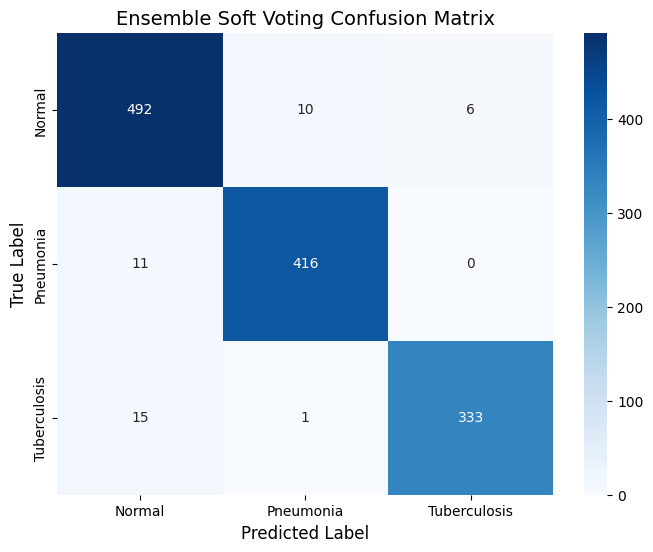

In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load all trained models from Google Drive
ensemble_models = []
print("Loading trained models from Google Drive...")

for model_name in models_to_train:
    model = initialize_model(model_name)
    weights_path = os.path.join(save_dir, f"{model_name}_best_weights.pth")

    # Load the state dict (mapping it to the correct device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval() # Strictly set to evaluation mode
    ensemble_models.append(model)

print("All 5 models successfully loaded and set to evaluation mode.")

# 2. Execute Soft Voting Inference
all_preds = []
all_labels = []

print("Running Soft Voting Ensemble on the Held-Out Test Set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Initialize a tensor to hold the cumulative probabilities
        batch_probs = torch.zeros((inputs.size(0), 3)).to(device)

        # Aggregate probabilities from each model
        for model in ensemble_models:
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            batch_probs += probs

        # Average the probabilities across the 5 models
        batch_probs /= len(ensemble_models)

        # Select the class with the highest average probability
        _, preds = torch.max(batch_probs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# # 3. Generate the Final Report Metrics
# class_names = dummy_dataset.classes

# The Kaggle dataset folders were misnamed. We map them to the correct medical
# classes based on the exact support distribution from the research paper.
# Index 0 ('Test' folder) = Normal
# Index 1 ('Train' folder) = Pneumonia
# Index 2 ('Validate' folder) = Tuberculosis
class_names = ['Normal', 'Pneumonia', 'Tuberculosis']

print("\n" + "="*50)
print(" ENSEMBLE EVALUATION RESULTS ")
print("="*50)

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"\nEnsemble Test Accuracy: {acc * 100:.2f}%")

# Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# 4. Visualize the Confusion Matrix (Required for your project report)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Ensemble Soft Voting Confusion Matrix', fontsize=14)
plt.show()